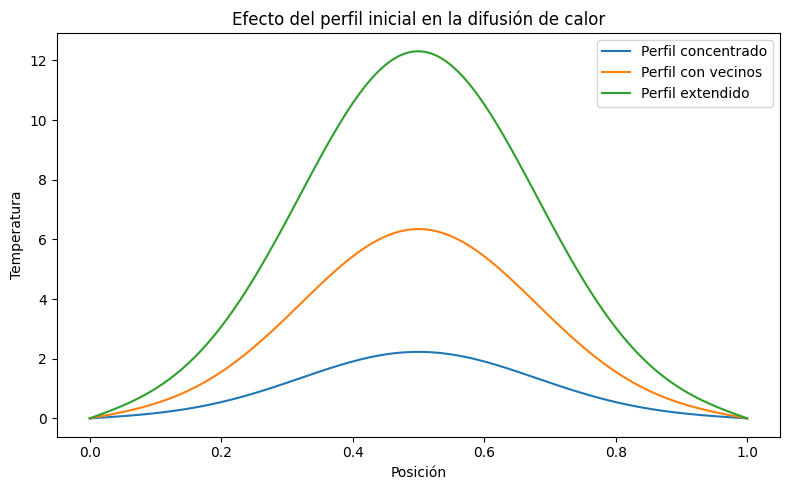

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# ACTIVIDAD: EFECTO DEL PERFIL INICIAL EN LA DIFUSION
# =====================================================

# Dominio
N = 101
L = 1.0
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Material
alpha = 0.01

# Paso temporal
dt = 0.4 * dx**2 / alpha

# Numero de pasos
steps = 400

# Perfiles iniciales
profiles = []

# Perfil 1: muy concentrado
T1 = np.zeros(N)
c = N // 2
T1[c] = 100.0

# Perfil 2: centro y vecinos
T2 = np.zeros(N)
T2[c] = 100.0
T2[c - 1] = 90.0
T2[c + 1] = 95.0

# Perfil 3: mas extendido
T3 = np.zeros(N)
T3[c] = 100.0
T3[c - 1] = 95.0
T3[c + 1] = 90.0
T3[c - 2] = 80.0
T3[c + 2] = 75.0
T3[c - 3] = 60.0
T3[c + 3] = 55.0

profiles.append(("Perfil concentrado", T1))
profiles.append(("Perfil con vecinos", T2))
profiles.append(("Perfil extendido", T3))

plt.figure(figsize=(8, 5))

for label, T in profiles:
    T = T.copy()

    for n in range(steps):
        T_new = T.copy()
        T_new[0] = 0.0
        T_new[-1] = 0.0

        for i in range(1, N - 1):
            T_new[i] = T[i] + alpha * dt / dx**2 * (T[i + 1] - 2*T[i] + T[i - 1])

        T = T_new

    plt.plot(x, T, label=label)

plt.xlabel("Posición")
plt.ylabel("Temperatura")
plt.title("Efecto del perfil inicial en la difusión de calor")
plt.legend()
plt.tight_layout()
plt.savefig("Difusion_Actividad.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Difusion_Actividad.pdf")